In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from cuthberto_carlos.data import download_data, to_jax_data
MAX_GOALS = 8

pd_data, _, _, _ = download_data(max_goals=MAX_GOALS)

train_data = pd_data[
    (pd_data['date'] > pd.to_datetime("2000-01-01"))
    & (pd_data['date'] < pd.to_datetime("2026-06-11"))
]
teams_id_to_name_dict = {int(row['home_team_id']): row['home_team'] for _, row in train_data.iterrows()}
jax_data = to_jax_data(train_data)
num_teams = len(teams_id_to_name_dict)
train_data.tail(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,timestamp_days,friendly,home_team_id,away_team_id,home_timestamp_previous,away_timestamp_previous
49400,2026-06-09,Iraq,Venezuela,0,2,Friendly,Bridgeview,United States,True,56073,True,137,313,56068,56070
49401,2026-06-10,Bolivia,Algeria,0,4,Friendly,Kansas City,United States,True,56074,True,35,4,56070,56067
49402,2026-06-10,England,Costa Rica,3,0,Friendly,Orlando,United States,True,56074,True,91,68,56070,56065
49403,2026-06-10,Portugal,Nigeria,2,1,Friendly,Leiria,Portugal,False,56074,True,226,203,56070,56067
49404,2026-06-10,Afghanistan,Pakistan,0,2,Diamond Jubilee International Football Tournament,Malé,Maldives,True,56074,False,1,215,56071,56071


# Distribution Diagnostics

In [3]:
output_path = REPO_ROOT / "scripts" / "smc" / "output" / "smc_filter_latest.npz"
latest_filter = np.load(output_path)['particles']  # Store the array, not the shape
latest_filter.shape  # Display the shape

(250, 308, 2)

In [4]:
TEAMS = ["France", "Germany", "Italy", "Spain", "England", "Portugal", "Netherlands", "Belgium"]
teams_name_to_id_dict = {v: k for k, v in teams_id_to_name_dict.items()}
team_ids = [teams_name_to_id_dict[name] for name in TEAMS]

print(f"Team IDs for {TEAMS}: {team_ids}")

selected_particles = latest_filter[:, team_ids, :]  # Shape: (N, 8, 2)
N = selected_particles.shape[0]

# Create DataFrame for pairplot: columns are "Team Attack" and "Team Defense"
data_dict = {}
for i, team in enumerate(TEAMS):
    data_dict[f"{team} Attack"] = selected_particles[:, i, 0]
    data_dict[f"{team} Defense"] = selected_particles[:, i, 1]

df_particles = pd.DataFrame(data_dict)

print(f"Particles shape: {latest_filter.shape}")
print(f"Selected particles shape: {selected_particles.shape}")
print(f"DataFrame shape: {df_particles.shape}")

Team IDs for ['France', 'Germany', 'Italy', 'Spain', 'England', 'Portugal', 'Netherlands', 'Belgium']: [102, 111, 142, 274, 91, 226, 198, 29]
Particles shape: (250, 308, 2)
Selected particles shape: (250, 8, 2)
DataFrame shape: (250, 16)


/Users/ryant/Github/cuthberto-carlos/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


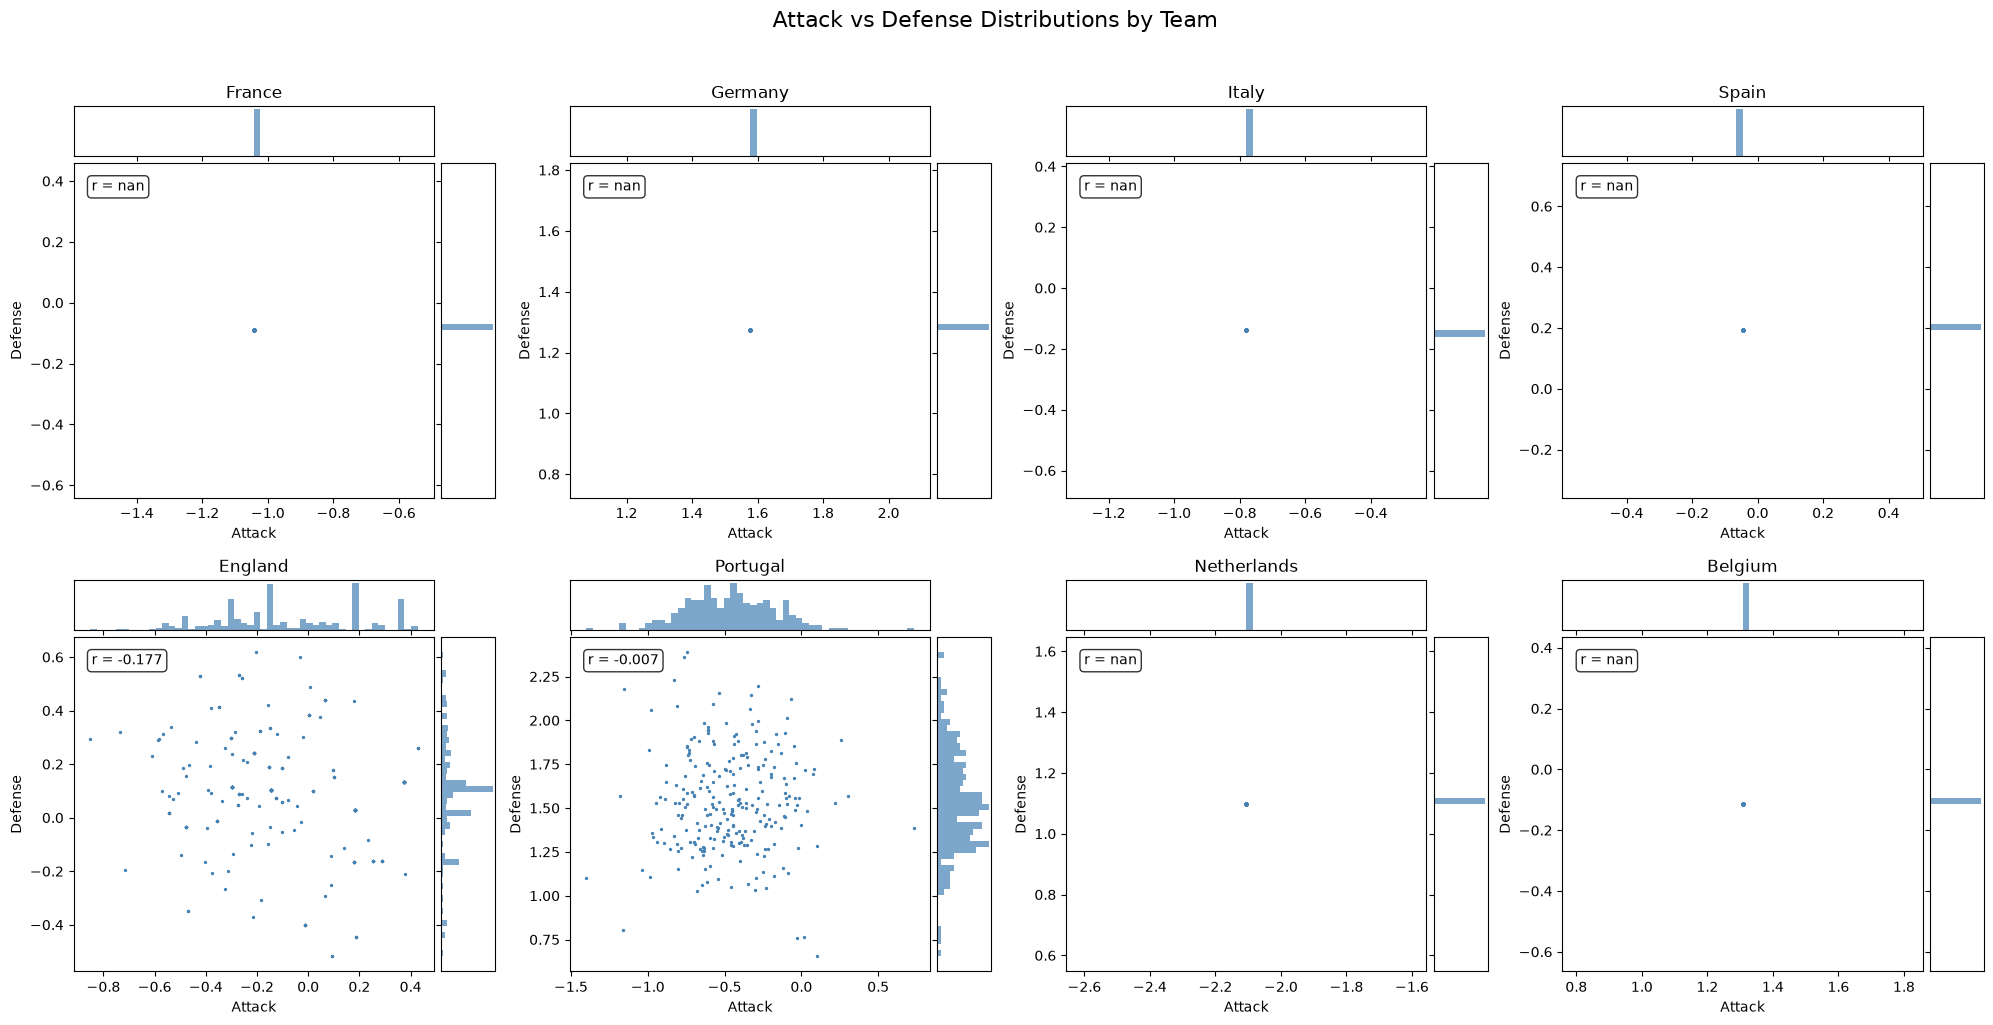

In [5]:
# Create a pairplot showing Attack vs Defense for each team
# Using seaborn's pairplot for the bivariate scatter with histograms

# Create a simplified DataFrame with just Attack and Defense columns
# We'll use hue to distinguish teams in a combined plot, or create subplots

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, team in enumerate(TEAMS):
    ax = axes[idx]
    
    attack = selected_particles[:, idx, 0]
    defense = selected_particles[:, idx, 1]
    
    # Main scatter plot
    ax.scatter(attack, defense, alpha=1, s=2, color='steelblue')
    
    # Add marginal histograms on top and right
    ax_histx = ax.inset_axes([0, 1.02, 1, 0.15], sharex=ax)
    ax_histy = ax.inset_axes([1.02, 0, 0.15, 1], sharey=ax)
    
    ax_histx.hist(attack, bins=50, alpha=0.7, color='steelblue', edgecolor='none')
    ax_histy.hist(defense, bins=50, alpha=0.7, color='steelblue', edgecolor='none', orientation='horizontal')
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histx.set_yticks([])
    ax_histy.set_xticks([])
    
    # Labels and title
    ax.set_xlabel('Attack')
    ax.set_ylabel('Defense')
    ax.set_title(f'{team}')
    
    # Add correlation coefficient
    corr = np.corrcoef(attack, defense)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Attack vs Defense Distributions by Team', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
